# 8.2 Biden Out, Harris In — Transition Period Analysis

Descriptive analysis of the 15-day window between Biden's withdrawal and Harris's formal nomination.

| # | Event | Date |
|---|-------|------|
| 1 | Biden withdraws / Harris announces candidacy | **July 21, 2024** |
| 2 | Obama endorses Harris | **July 24, 2024** |
| 3 | Harris formally nominated (virtual roll call) | **August 5, 2024** |

**Analysis window:** July 1 – August 31, 2024 (3 weeks pre/post context).

**Sections:**
1. The Attention Handoff (Google Trends)
2. Prediction Market Repricing (Polymarket)
3. Social Media Volume (Reddit & Bluesky)
4. Newspaper Coverage (Mediacloud)
5. Market Fear ≠ Political Fear (VIX vs. Media Calm)
6. Statistical Tests — Confirming What Moved (and What Didn't)

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.abspath('.'), '..', '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

import house_style as hs
from house_style import (
    apply_style, BG_DARK, BG_PANEL,
    REPUBLICAN, DEMOCRAT, NEUTRAL, ACCENT,
    TEXT_PRIMARY, TEXT_MUTED, GRID_COLOR, SPINE_COLOR,
    BUZZ_COLORS, BLUESKY_BLUE, REDDIT_ORG,
    C_VIX, C_FEAR, C_SADNESS,
)
apply_style()

# Colours not (yet) in house_style — defined locally
GOLD             = "#f0a500"   # gold/amber — Obama endorsement, Biden polymarket
TEAL             = "#2ec4b6"   # teal — policy search terms
PURPLE           = "#9b5de5"   # purple — Michelle Obama, NRC sadness
VIX_RED          = "#e05c5c"   # red — financial fear / VIX line
HARRIS_NOM_COLOR = "#5dade2"   # light blue — Harris nomination event line

BIDEN_OUT      = pd.Timestamp('2024-07-21')
OBAMA_ENDORSES = pd.Timestamp('2024-07-24')
HARRIS_NOM     = pd.Timestamp('2024-08-05')
WINDOW_START   = pd.Timestamp('2024-07-01')
WINDOW_END     = pd.Timestamp('2024-08-31')
DATA = os.path.join('..', '..', 'Data')

# Three event lines used across all plots
EVENTS3 = [
    (BIDEN_OUT,      'Biden withdraws',  DEMOCRAT),
    (OBAMA_ENDORSES, 'Obama endorses',   GOLD),
    (HARRIS_NOM,     'Harris nominated', HARRIS_NOM_COLOR),
]

def add_event_lines(ax, y_top=None, fontsize=7.5):
    for date, label, color in EVENTS3:
        ax.axvline(date, color=color, linestyle='--', linewidth=1.5, alpha=0.9, zorder=4)

def fmt_date_axis(ax):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
    ax.tick_params(axis='x', rotation=35)

print('Setup complete.')
print(f'  Biden withdraws : {BIDEN_OUT.date()}')
print(f'  Obama endorses  : {OBAMA_ENDORSES.date()}')
print(f'  Harris nominated: {HARRIS_NOM.date()}')


Setup complete.
  Biden withdraws : 2024-07-21
  Obama endorses  : 2024-07-24
  Harris nominated: 2024-08-05


## 0 — Early Warning Signals: Was Biden's Exit Anticipated?

Before Biden officially stepped aside on July 21, three independent signals were already pointing toward the exit:

1. **Prediction markets** — Biden's Polymarket win probability collapsed to 4.5% by July 19, two days before the announcement. Harris's probability rose in lockstep, suggesting markets were repricing the *candidate*, not the *party*.

2. **Social media language** — Reddit posts using exit-related language ("drop out", "step aside", "replace Biden") and age/fitness discourse were building steadily from mid-July onwards.

3. **Newspaper sentiment** — Editorial tone turned sharply negative after the June 27 presidential debate and again after the July 13 assassination attempt. By July 21, dem-leaning papers shifted positive — relief, not shock.

In [2]:
# ── Load data for pre-announcement window ────────────────────────────────────
PRE_START  = pd.Timestamp('2024-07-05')
PRE_END    = pd.Timestamp('2024-07-22')
TRUMP_SHOT = pd.Timestamp('2024-07-13')

EVENTS_PRE = [
    (TRUMP_SHOT, 'Trump shot',       REPUBLICAN),
    (BIDEN_OUT,  'Biden withdraws',  DEMOCRAT),
]

# Polymarket
pj = pd.read_csv(os.path.join(DATA, '1_bronze', 'polymarket', 'polymarket_july.csv'),
                 parse_dates=['date'])
pj_pre = pj[(pj['date'] >= PRE_START) & (pj['date'] <= PRE_END)].copy()

# Newspaper sentiment
sent = pd.read_csv(os.path.join(DATA, '2_silver', 'newspapers', 'sentiment_features_newspapers.csv'),
                   parse_dates=['date'])
sent_pre = sent[(sent['date'] >= PRE_START) & (sent['date'] <= PRE_END)].copy()

# Reddit exit-signal keyword counts
r_text = pd.read_parquet(os.path.join(DATA, '2_silver', 'reddit', 'reddit_posts_clean.parquet'),
                         columns=['created_utc', 'text_clean'])
r_text['date'] = pd.to_datetime(r_text['created_utc'], utc=True).dt.normalize().dt.tz_localize(None)
r_pre = r_text[(r_text['date'] >= PRE_START) & (r_text['date'] <= PRE_END)].copy()

EXIT_PAT = r'drop.{0,5}out|step.aside|withdraw|resign|replace.{0,8}biden|open.convention'
AGE_PAT  = r'\bage\b|\bold\b|fitness|cognitive|dementia|senile|mental.capacity'
r_pre['exit_signal'] = r_pre['text_clean'].str.contains(EXIT_PAT, case=False, na=False, regex=True)
r_pre['age_signal']  = r_pre['text_clean'].str.contains(AGE_PAT,  case=False, na=False, regex=True)

exit_daily = r_pre.groupby('date')['exit_signal'].sum().reindex(
    pd.date_range(PRE_START, PRE_END), fill_value=0)
age_daily  = r_pre.groupby('date')['age_signal'].sum().reindex(
    pd.date_range(PRE_START, PRE_END), fill_value=0)
exit_roll  = exit_daily.rolling(3, center=True, min_periods=1).mean()
age_roll   = age_daily.rolling(3, center=True, min_periods=1).mean()

# ── Figure: three stacked panels, shared x-axis ───────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Early Warning Signals — Before Biden Announced on July 21', fontweight='bold', fontsize=14)

# ── Panel 1: Polymarket probabilities ─────────────────────────────────────────
ax = axes[0]
ax.plot(pj_pre['date'], pj_pre['Joe Biden'],    color=GOLD, linewidth=2.2, label='Biden')
ax.plot(pj_pre['date'], pj_pre['Kamala Harris'], color=DEMOCRAT,  linewidth=2.2, label='Harris')
ax.fill_between(pj_pre['date'], pj_pre['Joe Biden'],    alpha=0.15, color=GOLD)
ax.fill_between(pj_pre['date'], pj_pre['Kamala Harris'], alpha=0.15, color=DEMOCRAT)
for date, lbl, color in EVENTS_PRE:
    ax.axvline(date, color=color, linestyle='--', linewidth=1.5, alpha=0.9, zorder=4)
ax.set_ylabel('Win probability (%)')
ax.set_title('Prediction market: Biden vs. Harris', loc='left', fontsize=11)
ax.legend(loc='upper left', fontsize=9)
ax.set_facecolor(BG_PANEL)

# ── Panel 2: Reddit exit-language signal ──────────────────────────────────────
ax2 = axes[1]
ax2.fill_between(exit_roll.index, exit_roll.values, alpha=0.30, color=DEMOCRAT)
ax2.fill_between(age_roll.index,  age_roll.values,  alpha=0.20, color=GOLD)
ax2.plot(exit_roll.index, exit_roll.values, color=DEMOCRAT,  linewidth=2.0,
         label='Exit language ("drop out", "step aside", "replace")')
ax2.plot(age_roll.index,  age_roll.values,  color=GOLD, linewidth=2.0, linestyle='--',
         label='Age / fitness discourse')
for date, lbl, color in EVENTS_PRE:
    ax2.axvline(date, color=color, linestyle='--', linewidth=1.5, alpha=0.9, zorder=4)
ax2.set_ylabel('Posts per day (3-day MA)')
ax2.set_title('Reddit: Biden-exit keyword signal', loc='left', fontsize=11)
ax2.legend(loc='upper left', fontsize=9)
ax2.set_facecolor(BG_PANEL)

# ── Panel 3: Newspaper VADER sentiment + NRC sadness ─────────────────────────
ax3 = axes[2]
ax3.plot(sent_pre['date'], sent_pre['vader_compound_mean_dem'], color=DEMOCRAT,
         linewidth=2.0, label='VADER sentiment — Dem-lean papers')
ax3.plot(sent_pre['date'], sent_pre['vader_compound_mean_rep'], color=REPUBLICAN,
         linewidth=2.0, linestyle='--', label='VADER sentiment — Rep-lean papers')
ax3.axhline(0, color=TEXT_MUTED, linestyle=':', linewidth=1.0, alpha=0.6)
ax3_r = ax3.twinx()
ax3_r.plot(sent_pre['date'], sent_pre['nrc_sadness_dem'], color=PURPLE,
           linewidth=1.6, linestyle='-.', alpha=0.8, label='NRC sadness — Dem-lean')
ax3_r.set_ylabel('NRC sadness score', color=PURPLE)
ax3_r.tick_params(axis='y', colors=PURPLE)
ax3_r.set_facecolor(BG_PANEL)
for date, lbl, color in EVENTS_PRE:
    ax3.axvline(date, color=color, linestyle='--', linewidth=1.5, alpha=0.9, zorder=4)
ax3.set_ylabel('VADER compound score')
ax3.set_title('Newspaper tone: VADER sentiment + NRC sadness', loc='left', fontsize=11)
ax3.legend(loc='lower left', fontsize=9)
ax3_r.legend(loc='lower right', fontsize=9)
ax3.set_facecolor(BG_PANEL)

fmt_date_axis(ax3)
plt.tight_layout()
plt.show()

print('Biden Polymarket probability July 19-21:')
for _, row in pj_pre[pj_pre['date'] >= '2024-07-19'].iterrows():
    print(f"  {row['date'].date()}  Biden={row['Joe Biden']:.1f}%  Harris={row['Kamala Harris']:.1f}%")
print(f'\nReddit exit-signal posts Jul 17-21:')
for d in pd.date_range('2024-07-17', '2024-07-21'):
    print(f'  {d.date()}  exit={int(exit_daily.get(d, 0))}  age={int(age_daily.get(d, 0))}')


FileNotFoundError: [Errno 2] No such file or directory: '..\\..\\Data\\1_bronze\\polymarket\\polymarket_july.csv'

## 1 — The Attention Handoff

Google Search Trends track where public attention flows. With Biden out, Kamala's search interest surged sharply — the right panel shows which *policy issues* moved in tandem, revealing what the public suddenly wanted to know about the new candidate.

The Obama endorsement on July 24 produced a secondary boost, confirming sustained momentum rather than a one-day curiosity spike.

Trends columns: ['date', 'trump', 'kamala', 'Border security', 'Deportation', 'Inflation', 'Energy production', 'Manufacturing', 'Tax cuts', 'Housing affordability', 'Small business', 'Reproductive rights', 'Civil rights']


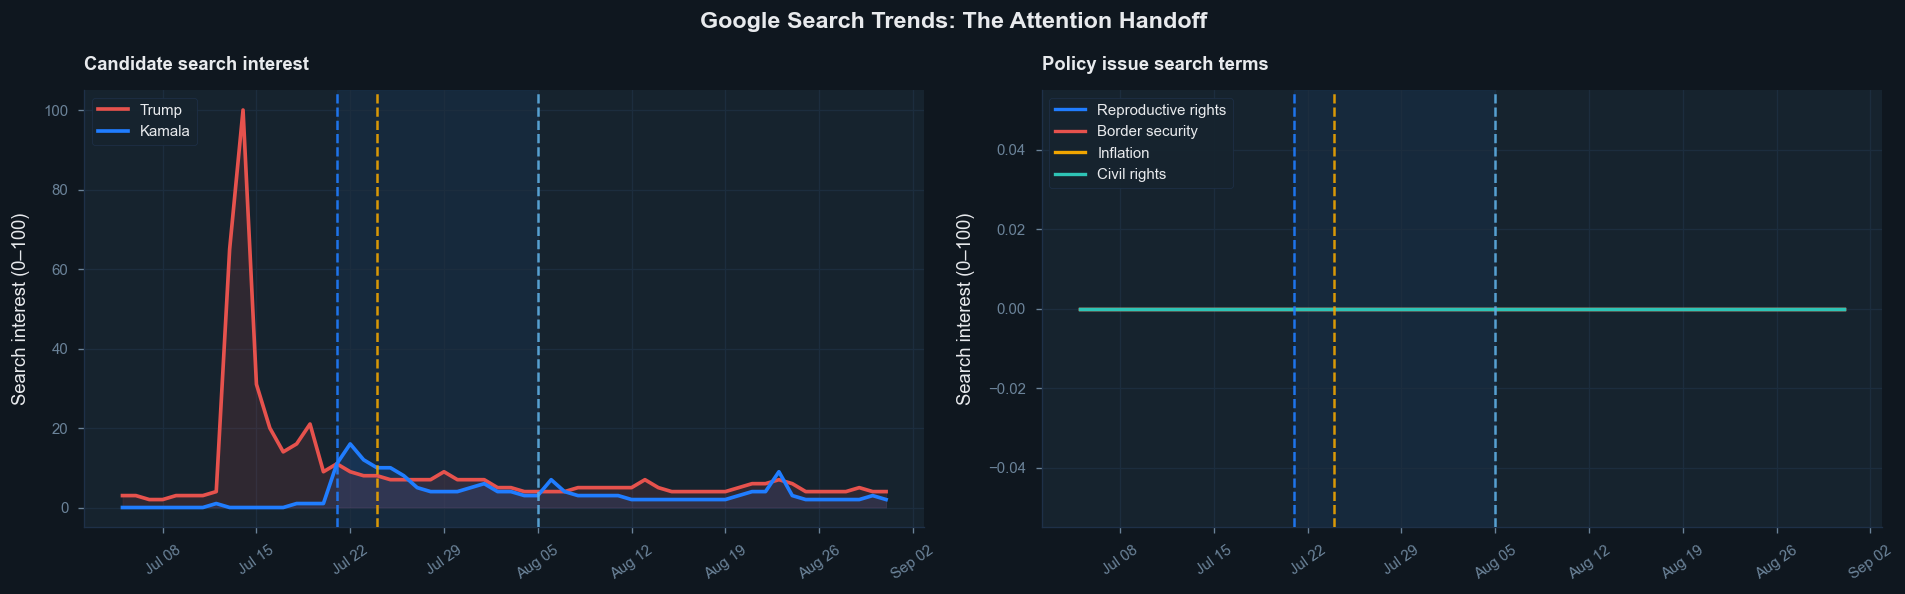

Search interest — one day before / one day after Biden withdrawal:
  Kamala    before=1  after=16  delta=+15
  Trump     before=9  after=9  delta=+0


: 

In [ ]:
trends = pd.read_csv(
    os.path.join(DATA, '1_bronze', 'google_trends', 'trends_daily_stitched.csv'),
    parse_dates=['date'])
tr = trends[(trends['date'] >= WINDOW_START) & (trends['date'] <= WINDOW_END)].copy()
print('Trends columns:', tr.columns.tolist())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Google Search Trends: The Attention Handoff', fontweight='bold', fontsize=14)

# Left: Trump vs Kamala attention
ax = axes[0]
ax.fill_between(tr['date'], tr['kamala'], alpha=0.12, color=DEMOCRAT)
ax.fill_between(tr['date'], tr['trump'],  alpha=0.12, color=REPUBLICAN)
ax.plot(tr['date'], tr['trump'],  color=REPUBLICAN, linewidth=2.2, label='Trump')
ax.plot(tr['date'], tr['kamala'], color=DEMOCRAT,   linewidth=2.2, label='Kamala')
ax.axvspan(BIDEN_OUT, HARRIS_NOM, alpha=0.07, color=DEMOCRAT, zorder=0)
add_event_lines(ax)
fmt_date_axis(ax)
ax.set_ylabel('Search interest (0–100)')
ax.set_title('Candidate search interest', loc='left', fontsize=11)
ax.legend(loc='upper left')

# Right: policy issue searches — which issues surged with the new candidate?
policy_terms = [
    ('Reproductive rights', DEMOCRAT),
    ('Border security',     REPUBLICAN),
    ('Inflation',           GOLD),
    ('Civil rights',        TEAL),
]
ax2 = axes[1]
for term, color in policy_terms:
    if term in tr.columns:
        ax2.plot(tr['date'], tr[term], color=color, linewidth=2.0, label=term)
ax2.axvspan(BIDEN_OUT, HARRIS_NOM, alpha=0.07, color=DEMOCRAT, zorder=0)
add_event_lines(ax2)
fmt_date_axis(ax2)
ax2.set_ylabel('Search interest (0–100)')
ax2.set_title('Policy issue search terms', loc='left', fontsize=11)
ax2.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Quantify the crossover
row_before = tr[tr['date'] == BIDEN_OUT - pd.Timedelta(days=1)]
row_after  = tr[tr['date'] == BIDEN_OUT + pd.Timedelta(days=1)]
if not row_before.empty and not row_after.empty:
    print('Search interest — one day before / one day after Biden withdrawal:')
    for col in ['kamala', 'trump']:
        b = row_before[col].values[0]
        a = row_after[col].values[0]
        print(f'  {col.capitalize():8s}  before={b:.0f}  after={a:.0f}  delta={a-b:+.0f}')


## 2 — Prediction Market Repricing

Polymarket shows how *real money* recalibrated the election. The left panel tracks Trump vs. Harris win probability over the full window. The right panel zooms into July's individual candidate market — revealing the brief window where Michelle Obama and Gavin Newsom attracted speculative bets before the market consolidated around Harris.

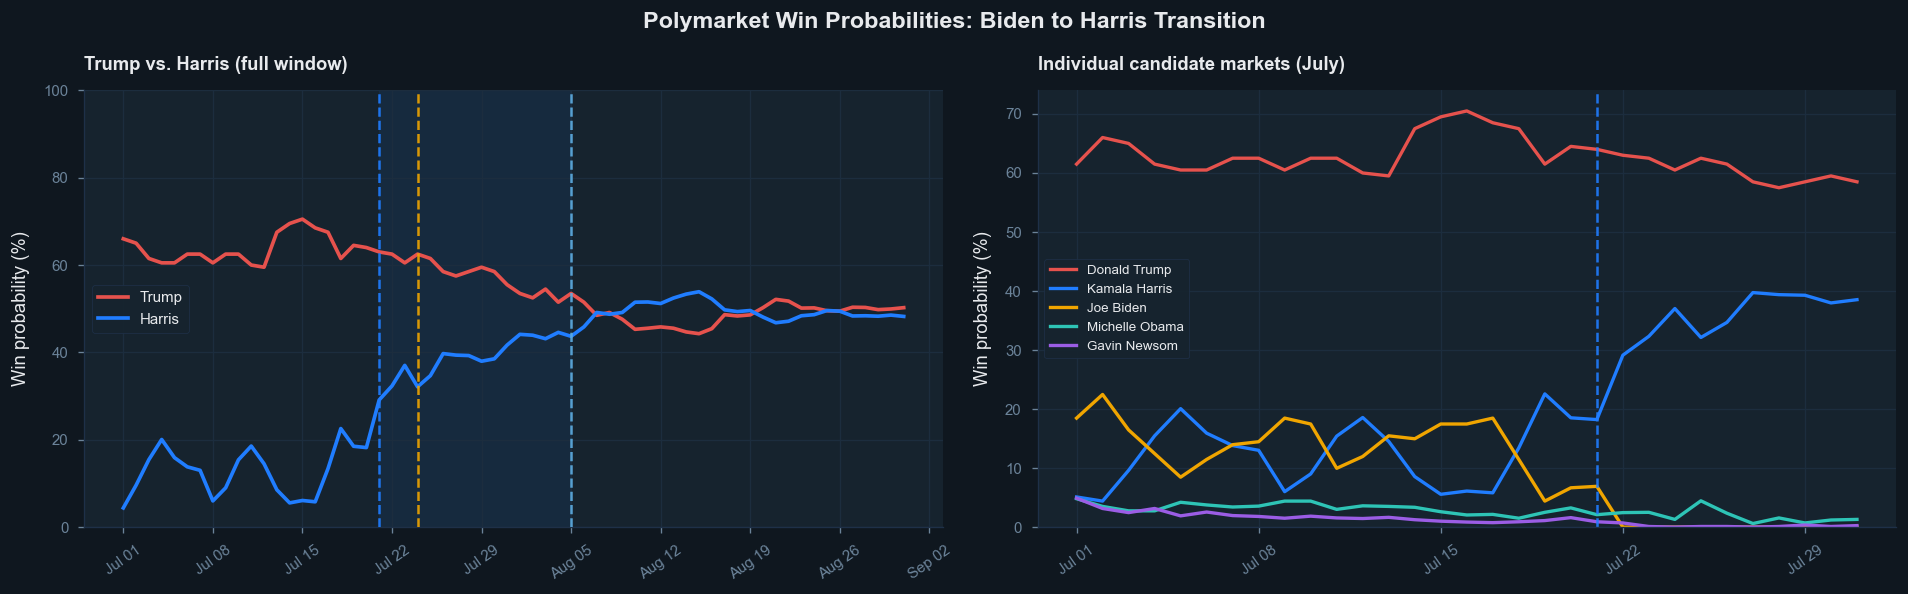

Transition window (Jul 21 – Aug 5) Polymarket change:
  Trump:  63.0% -> 53.5%  (-9.5 pp)
  Harris: 29.1% -> 43.7%  (+14.6 pp)


: 

In [ ]:
poly_win  = pd.read_csv(os.path.join(DATA, '1_bronze', 'polymarket', 'polymarket_win_probabilities.csv'), parse_dates=['date'])
poly_july = pd.read_csv(os.path.join(DATA, '1_bronze', 'polymarket', 'polymarket_july.csv'),             parse_dates=['date'])
pw = poly_win[(poly_win['date']  >= WINDOW_START) & (poly_win['date']  <= WINDOW_END)].copy()
pj = poly_july[(poly_july['date'] >= WINDOW_START) & (poly_july['date'] <= WINDOW_END)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Polymarket Win Probabilities: Biden to Harris Transition', fontweight='bold', fontsize=14)

ax = axes[0]
ax.plot(pw['date'], pw['Trump (%)'],  color=REPUBLICAN, linewidth=2.2, label='Trump')
ax.plot(pw['date'], pw['Harris (%)'], color=DEMOCRAT,   linewidth=2.2, label='Harris')
ax.axvspan(BIDEN_OUT, HARRIS_NOM, alpha=0.08, color=DEMOCRAT, zorder=0)
add_event_lines(ax, y_top=100)
fmt_date_axis(ax)
ax.set_ylabel('Win probability (%)')
ax.set_ylim(0, 100)
ax.set_title('Trump vs. Harris (full window)', loc='left', fontsize=11)
ax.legend(loc='center left')

cands = {'Donald Trump': REPUBLICAN, 'Kamala Harris': DEMOCRAT,
         'Joe Biden': GOLD, 'Michelle Obama': TEAL, 'Gavin Newsom': PURPLE}
ax2 = axes[1]
for cand, color in cands.items():
    if cand in pj.columns:
        ax2.plot(pj['date'], pj[cand], color=color, linewidth=2.0, label=cand)
ax2.axvline(BIDEN_OUT, color=DEMOCRAT, linestyle='--', linewidth=1.5, alpha=0.9)
fmt_date_axis(ax2)
ax2.set_ylabel('Win probability (%)')
ax2.set_ylim(0)
ax2.set_title('Individual candidate markets (July)', loc='left', fontsize=11)
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

trans = pw[(pw['date'] >= BIDEN_OUT) & (pw['date'] <= HARRIS_NOM)]
if len(trans) >= 2:
    dt = trans['Trump (%)'].iloc[-1] - trans['Trump (%)'].iloc[0]
    dh = trans['Harris (%)'].iloc[-1] - trans['Harris (%)'].iloc[0]
    print(f'Transition window (Jul 21 – Aug 5) Polymarket change:')
    print(f'  Trump:  {trans["Trump (%)"].iloc[0]:.1f}% -> {trans["Trump (%)"].iloc[-1]:.1f}%  ({dt:+.1f} pp)')
    print(f'  Harris: {trans["Harris (%)"].iloc[0]:.1f}% -> {trans["Harris (%)"].iloc[-1]:.1f}%  ({dh:+.1f} pp)')


## 3 — Social Media Volume

Daily post counts on Reddit and Bluesky split by buzz cluster. The Obama endorsement (July 24) shows up as a clear secondary peak in HarrisBuzz, distinct from the initial withdrawal spike — suggesting that *sustained* mobilisation, not just a novelty reaction.

> **Buzz labels** reflect which *hashtag cluster* a post came from, not the author's stance.

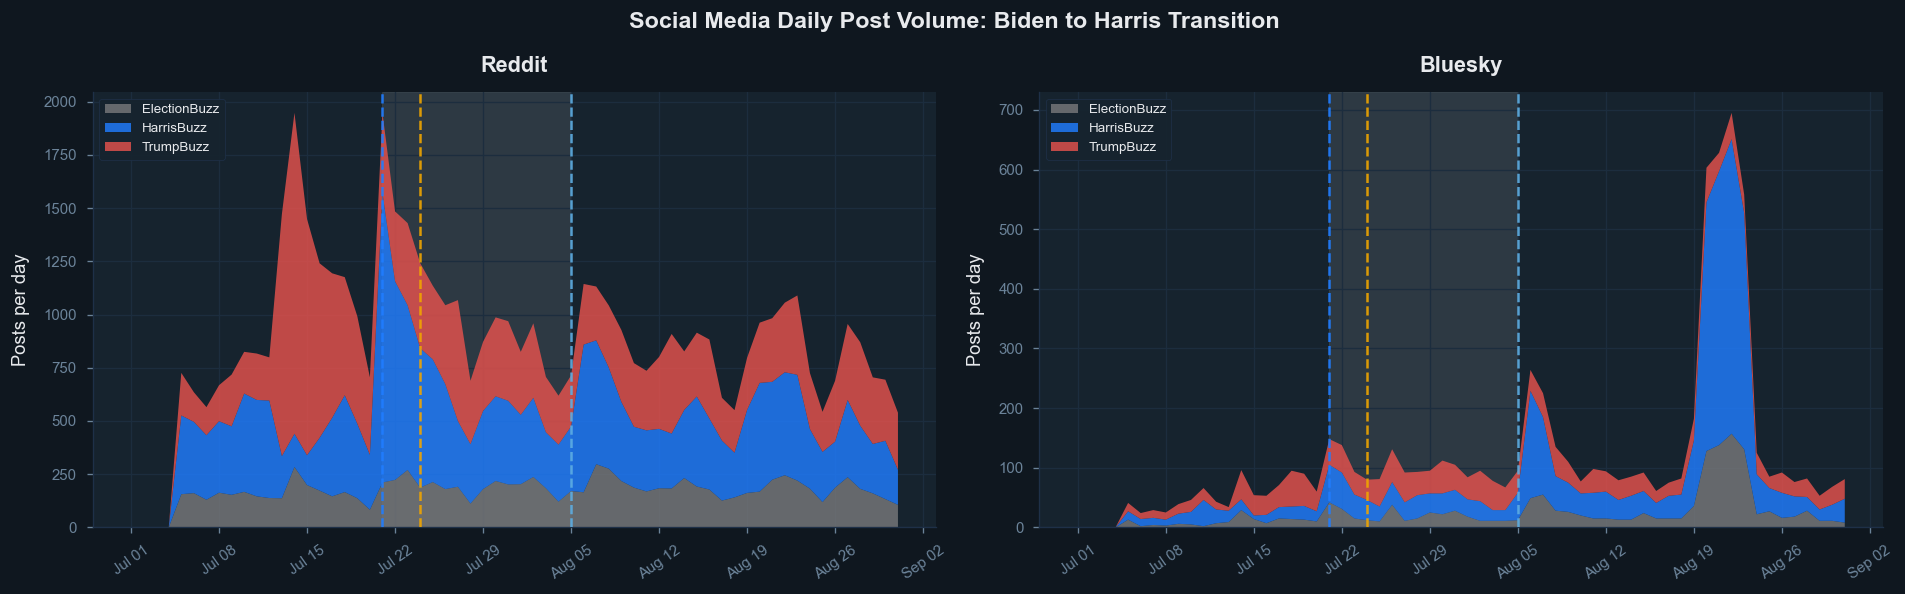

: 

In [ ]:
reddit = pd.read_parquet(os.path.join(DATA, '2_silver', 'reddit', 'reddit_posts_clean.parquet'),
                         columns=['created_utc', 'candidate', 'score', 'num_comments'])
reddit['date'] = pd.to_datetime(reddit['created_utc'], utc=True).dt.normalize().dt.tz_localize(None)
reddit_w = reddit[(reddit['date'] >= WINDOW_START) & (reddit['date'] <= WINDOW_END)].copy()

bsky = pd.read_csv(os.path.join(DATA, '2_silver', 'bluesky', 'bluesky_clean.csv'),
                   usecols=['timestamp', 'candidate', 'likes', 'reposts', 'replies'])
bsky['date'] = pd.to_datetime(bsky['timestamp'], format='mixed', utc=True).dt.normalize().dt.tz_localize(None)
bsky_w = bsky[(bsky['date'] >= WINDOW_START) & (bsky['date'] <= WINDOW_END)].copy()

reddit_daily = (reddit_w.groupby(['date', 'candidate']).size()
                .unstack(fill_value=0)
                .reindex(pd.date_range(WINDOW_START, WINDOW_END), fill_value=0))
bsky_daily   = (bsky_w.groupby(['date', 'candidate']).size()
                .unstack(fill_value=0)
                .reindex(pd.date_range(WINDOW_START, WINDOW_END), fill_value=0))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Social Media Daily Post Volume: Biden to Harris Transition', fontweight='bold', fontsize=14)

for ax, daily, title in [(axes[0], reddit_daily, 'Reddit'), (axes[1], bsky_daily, 'Bluesky')]:
    order  = ['ElectionBuzz', 'HarrisBuzz', 'TrumpBuzz']
    cols   = [c for c in order if c in daily.columns]
    colors = [BUZZ_COLORS[c] for c in cols]
    ax.stackplot(daily.index, [daily[c] for c in cols], labels=cols, colors=colors, alpha=0.82)
    ax.axvspan(BIDEN_OUT, HARRIS_NOM, alpha=0.1, color='white', zorder=0)
    for date, lbl, color in EVENTS3:
        ax.axvline(date, color=color, linestyle='--', linewidth=1.5, alpha=0.9, zorder=4)
    fmt_date_axis(ax)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Posts per day')
    ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()


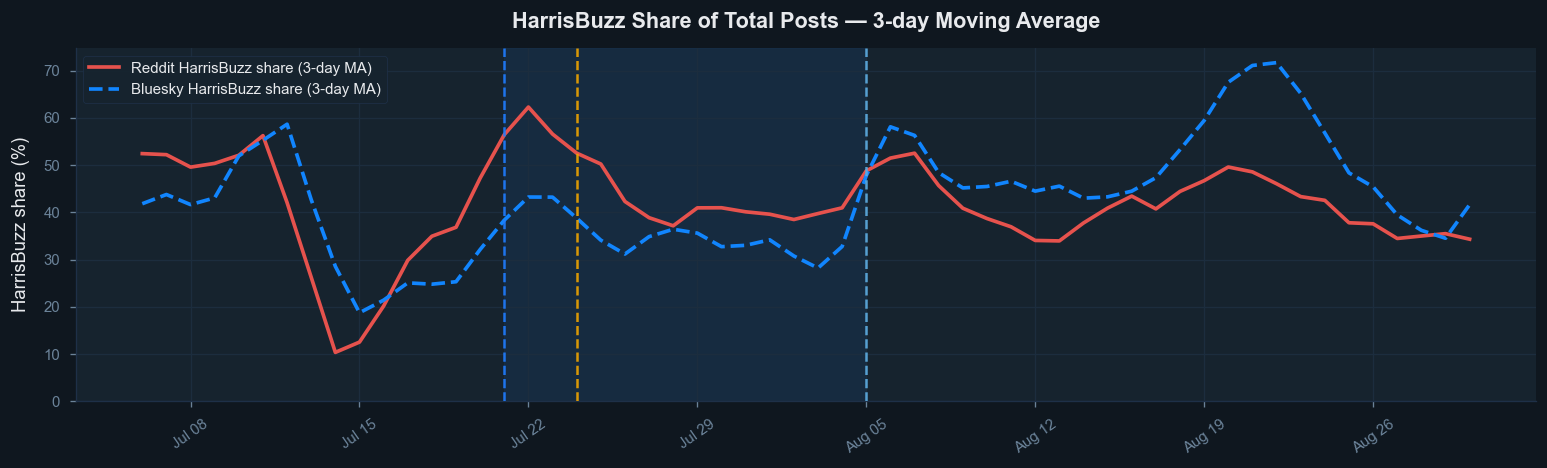

: 

In [ ]:
# HarrisBuzz share — 3-day rolling average on both platforms
fig, ax = plt.subplots(figsize=(13, 4))
fig.patch.set_facecolor(BG_DARK)

for daily, label, color, ls in [
    (reddit_daily, 'Reddit',  REPUBLICAN, '-'),
    (bsky_daily,   'Bluesky', BLUESKY_BLUE, '--'),
]:
    total = daily.sum(axis=1).replace(0, np.nan)
    share = daily.get('HarrisBuzz', pd.Series(0, index=daily.index)) / total * 100
    ax.plot(daily.index, share.rolling(3, center=True).mean(),
            color=color, linewidth=2.2, linestyle=ls,
            label=f'{label} HarrisBuzz share (3-day MA)')

ax.axvspan(BIDEN_OUT, HARRIS_NOM, alpha=0.09, color=DEMOCRAT, zorder=0)
for date, lbl, color in EVENTS3:
    ax.axvline(date, color=color, linestyle='--', linewidth=1.5, alpha=0.9, zorder=4)
fmt_date_axis(ax)
ax.set_title('HarrisBuzz Share of Total Posts — 3-day Moving Average', fontweight='bold')
ax.set_ylabel('HarrisBuzz share (%)')
ax.set_ylim(0)
ax.legend()
plt.tight_layout()
plt.show()


## 3b — July 21: Hour-by-Hour Social Media Reaction

Key moment: **17:40 UTC** — Biden steps aside as Democratic nominee.

The hourly breakdown reveals how fast each platform reacted and which buzz cluster drove the spike.

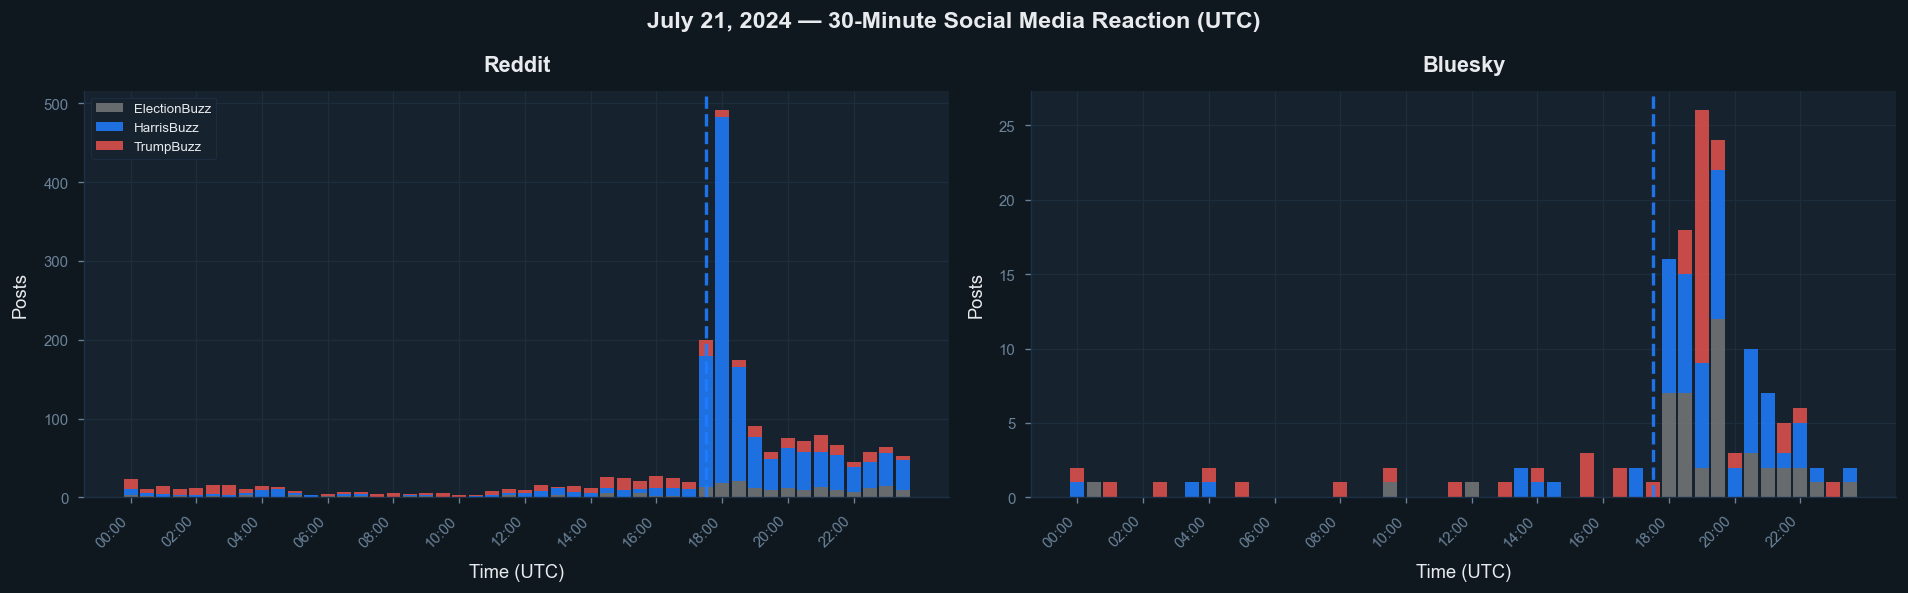

Reddit: peak total=18:00 UTC (491 posts), HarrisBuzz peak=18:00 UTC (465 posts)
Bluesky: peak total=19:00 UTC (26 posts), HarrisBuzz peak=19:30 UTC (10 posts)


: 

In [ ]:
# Derive 30-minute bin timestamps for July 21
reddit_21 = reddit_w[reddit_w['date'] == pd.Timestamp('2024-07-21')].copy()
_rdt = pd.to_datetime(reddit_21['created_utc'], utc=True)
reddit_21['bin30'] = _rdt.dt.hour * 2 + (_rdt.dt.minute >= 30).astype(int)

bsky_21 = bsky_w[bsky_w['date'] == pd.Timestamp('2024-07-21')].copy()
_bdt = pd.to_datetime(bsky_21['timestamp'], format='mixed', utc=True)
bsky_21['bin30'] = _bdt.dt.hour * 2 + (_bdt.dt.minute >= 30).astype(int)

order = ['ElectionBuzz', 'HarrisBuzz', 'TrumpBuzz']
bins  = range(48)   # 0 = 00:00–00:29 … 47 = 23:30–23:59

def bin30_stacked(df):
    g = df.groupby(['bin30', 'candidate']).size().unstack(fill_value=0)
    return g.reindex(index=bins, columns=order, fill_value=0)

rh = bin30_stacked(reddit_21)
bh = bin30_stacked(bsky_21)

# Event marker: 17:40 UTC → bin 35  (17*2 + 1, since 40 >= 30)
BIDEN_BIN = 17 * 2 + 1  # = 35

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('July 21, 2024 — 30-Minute Social Media Reaction (UTC)', fontweight='bold', fontsize=14)

# Ticks every 2 hours (every 4 bins)
tick_bins   = list(range(0, 48, 4))
tick_labels = [f'{b // 2:02d}:00' for b in tick_bins]

for i, (ax, dh, title) in enumerate([(axes[0], rh, 'Reddit'), (axes[1], bh, 'Bluesky')]):
    cols   = [c for c in order if c in dh.columns]
    colors = [BUZZ_COLORS[c] for c in cols]
    bottom = np.zeros(48)
    for col, color in zip(cols, colors):
        ax.bar(list(bins), dh[col].values, bottom=bottom,
               color=color, alpha=0.85, label=col, width=0.85)
        bottom += dh[col].values

    ax.axvline(BIDEN_BIN, color=DEMOCRAT, linestyle='--', linewidth=2.0, alpha=0.9, zorder=5)

    ax.set_xlabel('Time (UTC)')
    ax.set_ylabel('Posts')
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(tick_bins)
    ax.set_xticklabels(tick_labels, rotation=45, ha='right')
    ax.set_facecolor(BG_PANEL)
    if i == 0:
        ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

# Print peak 30-min bins
for name, dh in [('Reddit', rh), ('Bluesky', bh)]:
    total_by_bin = dh.sum(axis=1)
    peak_b = total_by_bin.idxmax()
    peak_h, peak_m = peak_b // 2, (peak_b % 2) * 30
    harris_col = dh.get('HarrisBuzz', pd.Series(0, index=dh.index))
    harris_peak_b = harris_col.idxmax()
    hp_h, hp_m = harris_peak_b // 2, (harris_peak_b % 2) * 30
    print(f'{name}: peak total={peak_h:02d}:{peak_m:02d} UTC ({total_by_bin[peak_b]} posts), '
          f'HarrisBuzz peak={hp_h:02d}:{hp_m:02d} UTC ({harris_col[harris_peak_b]} posts)')


## 3c — Platform Personality: What Did Each Platform Actually Say?

The hourly counts tell *when* people reacted. This section digs into *what* they said.

**Two questions:**
1. **Reddit** — which narrative threads drove the HarrisBuzz spike, and which communities led the conversation?
2. **Cross-platform** — did Reddit and Bluesky use the same language, or did each platform have a distinct voice?

Method: NMF topic modelling on Reddit HarrisBuzz posts (n = 1,361); log-odds ratio for platform vocabulary divergence.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF as sklNMF

# ── Reload with text columns (section 3 loaded only volume columns) ──────────
reddit_text = pd.read_parquet(
    os.path.join(DATA, '2_silver', 'reddit', 'reddit_posts_clean.parquet'),
    columns=['created_utc', 'candidate', 'subreddit', 'text_clean', 'score'])
reddit_text['date'] = pd.to_datetime(reddit_text['created_utc'], utc=True).dt.normalize().dt.tz_localize(None)

bsky_text = pd.read_csv(
    os.path.join(DATA, '2_silver', 'bluesky', 'bluesky_clean.csv'),
    usecols=['timestamp', 'candidate', 'text_clean', 'likes', 'reposts'])
bsky_text['date'] = pd.to_datetime(bsky_text['timestamp'], format='mixed', utc=True).dt.normalize().dt.tz_localize(None)

# ── Data slices ───────────────────────────────────────────────────────────────
r21 = reddit_text[reddit_text['date'] == pd.Timestamp('2024-07-21')].copy()
b21 = bsky_text[bsky_text['date']     == pd.Timestamp('2024-07-21')].copy()

r_harris_docs = r21[r21['candidate'] == 'HarrisBuzz']['text_clean'].dropna().astype(str).tolist()
r_all_docs    = r21['text_clean'].dropna().astype(str).tolist()
b_all_docs    = b21['text_clean'].dropna().astype(str).tolist()

print(f'Reddit HarrisBuzz docs : {len(r_harris_docs)}')
print(f'Reddit all docs        : {len(r_all_docs)}')
print(f'Bluesky all docs       : {len(b_all_docs)}')

# ── NMF topic model on Reddit HarrisBuzz ─────────────────────────────────────
vec_nmf = TfidfVectorizer(max_features=600, min_df=3, max_df=0.85, ngram_range=(1, 2))
X_nmf   = vec_nmf.fit_transform(r_harris_docs)
nmf_model = sklNMF(n_components=4, random_state=42, max_iter=400)
nmf_model.fit(X_nmf)
terms_nmf = vec_nmf.get_feature_names_out()

N_WORDS = 6
topics = []
for comp in nmf_model.components_:
    top_w = [terms_nmf[j] for j in comp.argsort()[-N_WORDS:][::-1]]
    topics.append(top_w)

for i, t in enumerate(topics):
    print(f'Topic {i+1}: {t}')

# ── Log-odds divergence ───────────────────────────────────────────────────────
all_docs = r_all_docs + b_all_docs
n_r, n_b = len(r_all_docs), len(b_all_docs)

vec_lo   = TfidfVectorizer(max_features=1000, min_df=2, max_df=0.9, ngram_range=(1, 1))
X_lo     = vec_lo.fit_transform(all_docs)
lo_terms = vec_lo.get_feature_names_out()

r_freq = np.asarray(X_lo[:n_r].sum(axis=0)).flatten()
b_freq = np.asarray(X_lo[n_r:].sum(axis=0)).flatten()
r_norm = (r_freq + 1) / (n_r + 1)
b_norm = (b_freq + 1) / (n_b + 1)
log_odds = np.log(r_norm / b_norm)

r_doc_freq = np.asarray((X_lo[:n_r] > 0).sum(axis=0)).flatten()
b_doc_freq = np.asarray((X_lo[n_r:] > 0).sum(axis=0)).flatten()

N_SHOW = 12
top_r = sorted(
    [(lo_terms[i], log_odds[i]) for i in range(len(lo_terms)) if r_doc_freq[i] >= 5],
    key=lambda x: x[1], reverse=True
)[:N_SHOW]

top_b = sorted(
    [(lo_terms[i], -log_odds[i]) for i in range(len(lo_terms)) if b_doc_freq[i] >= 3],
    key=lambda x: x[1], reverse=True
)[:N_SHOW]

print('\nReddit-distinctive :', [w for w, _ in top_r])
print('Bluesky-distinctive:', [w for w, _ in top_b])


Reddit HarrisBuzz docs : 1361
Reddit all docs        : 1947
Bluesky all docs       : 148
Topic 1: ['biden drops', 'drops', 'drops presidential', 'presidential race', 'race', 'presidential']
Topic 2: ['harris', 'kamala', 'kamala harris', 'endorses', 'endorses kamala', 'democratic']
Topic 3: ['joe', 'joe biden', 'election', 'biden presidential', 'biden', 'presidential election']
Topic 4: ['biden pulls', 'pulls', 'pulls presidential', 'race', 'presidential race', 'biden']

Reddit-distinctive : ['drops', 'joe', 'presidential', 'race', 'biden', 'pulls', 'democratic', 'dropped', 'election', 'kamala', 'announces', 'endorses']
Bluesky-distinctive: ['votekamala', 'demented', 'kamalaharris', 'bidenout', 'malignant', 'treasonous', 'donaldtrump', 'felonious', 'fucking', 'nazi', 'puppet', 'rapey']


: 

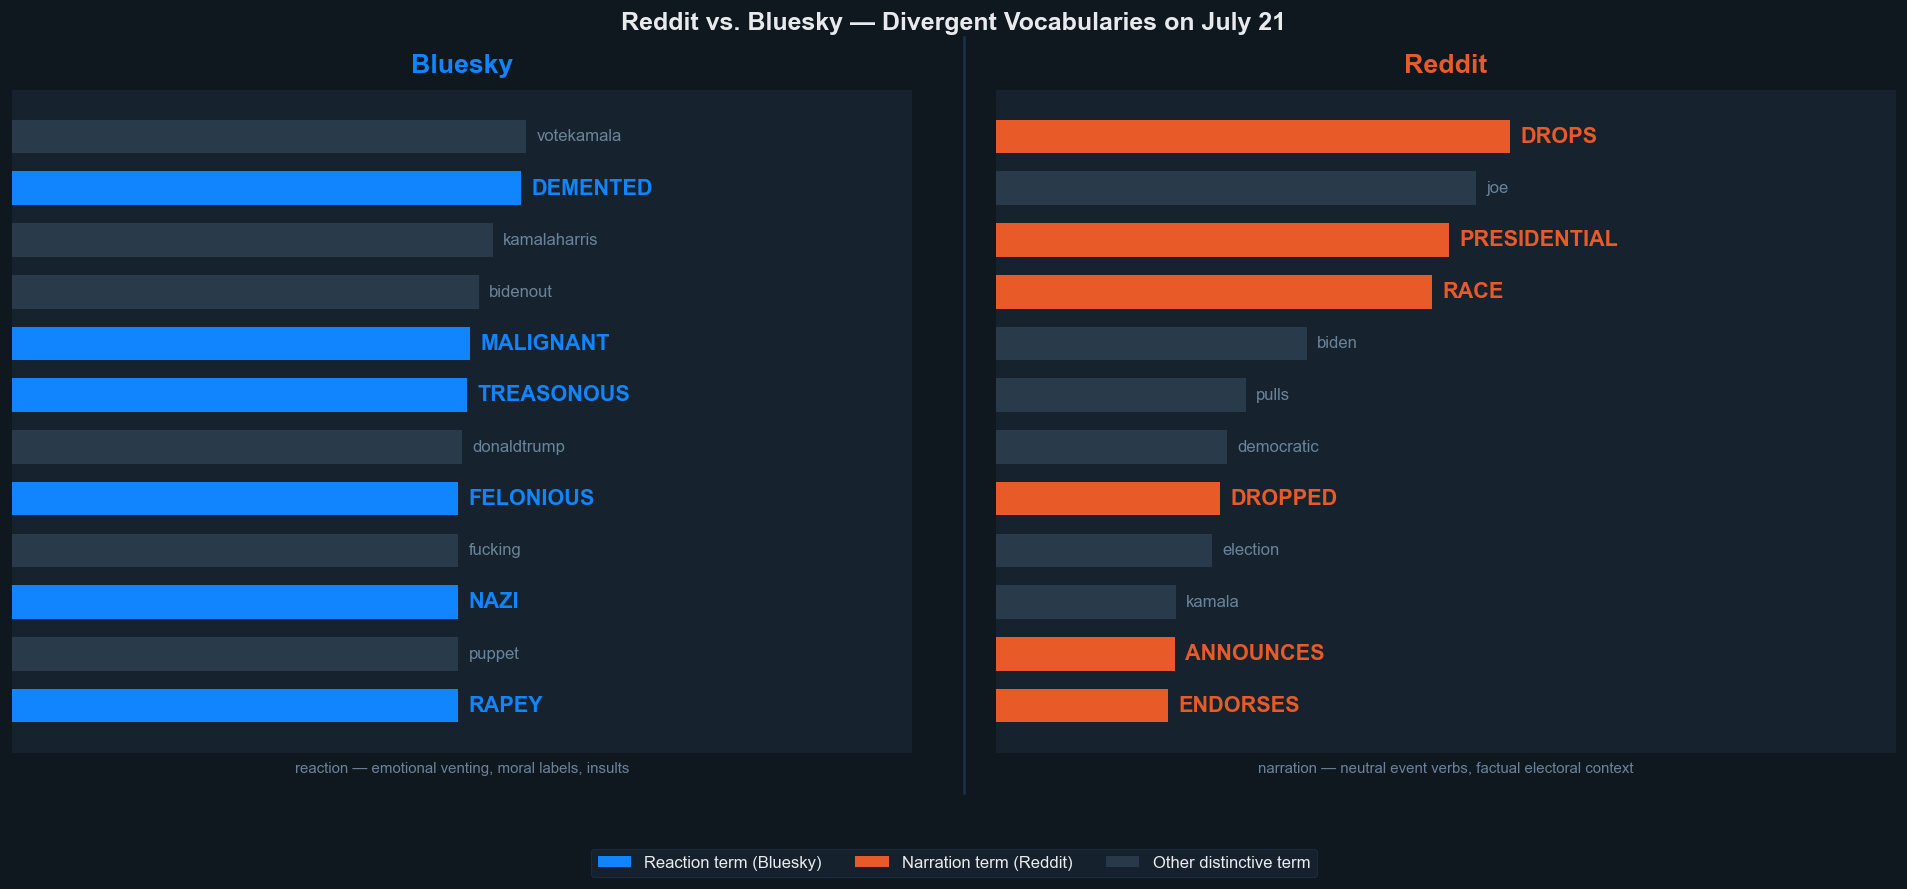

: 

In [ ]:
# ── Figure 1: Cross-platform vocabulary divergence (slide style) ──────────────
# Reaction = Bluesky: emotional venting, insults, moral labels, hashtag mobilisation
# Narration = Reddit: neutral event verbs, electoral process vocabulary
REACTION_BSKY = {'demented', 'malignant', 'rapey', 'treasonous', 'felonious', 'nazi'}
NARRATION_REDDIT = {'drops', 'dropped', 'presidential', 'race', 'announces', 'endorses'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Reddit vs. Bluesky — Divergent Vocabularies on July 21',
             fontweight='bold', fontsize=15)

# ── Left: Bluesky-distinctive ─────────────────────────────────────────────────
ax_b = axes[0]
ax_b.set_facecolor(BG_PANEL)
words_b = [w for w, _ in top_b[::-1]]
vals_b  = [v for _, v in top_b[::-1]]
max_b   = max(vals_b) if vals_b else 1

bars_b = ax_b.barh(
    range(len(words_b)), vals_b,
    color=[BLUESKY_BLUE if w in REACTION_BSKY else '#3d5166' for w in words_b],
    height=0.65, edgecolor='none',
)
for bar, w in zip(bars_b, words_b):
    bar.set_alpha(1.0 if w in REACTION_BSKY else 0.5)
for i, (w, v) in enumerate(zip(words_b, vals_b)):
    ax_b.text(v + max_b * 0.02, i,
              w.upper() if w in REACTION_BSKY else w,
              va='center', ha='left',
              fontsize=13 if w in REACTION_BSKY else 10,
              fontweight='bold' if w in REACTION_BSKY else 'normal',
              color=BLUESKY_BLUE if w in REACTION_BSKY else TEXT_MUTED)
ax_b.set_yticks([])
ax_b.set_xticks([])
ax_b.set_xlim(0, max_b * 1.75)
for s in ax_b.spines.values(): s.set_visible(False)
ax_b.set_title('Bluesky', color=BLUESKY_BLUE, fontweight='bold', fontsize=16, pad=10)
ax_b.annotate('reaction — emotional venting, moral labels, insults',
              xy=(0.5, -0.03), xycoords='axes fraction',
              ha='center', fontsize=9, color=TEXT_MUTED)

# ── Right: Reddit-distinctive ─────────────────────────────────────────────────
ax_r = axes[1]
ax_r.set_facecolor(BG_PANEL)
words_r = [w for w, _ in top_r[::-1]]
vals_r  = [v for _, v in top_r[::-1]]
max_r   = max(vals_r) if vals_r else 1

bars_r = ax_r.barh(
    range(len(words_r)), vals_r,
    color=[REDDIT_ORG if w in NARRATION_REDDIT else '#3d5166' for w in words_r],
    height=0.65, edgecolor='none',
)
for bar, w in zip(bars_r, words_r):
    bar.set_alpha(1.0 if w in NARRATION_REDDIT else 0.5)
for i, (w, v) in enumerate(zip(words_r, vals_r)):
    ax_r.text(v + max_r * 0.02, i,
              w.upper() if w in NARRATION_REDDIT else w,
              va='center', ha='left',
              fontsize=13 if w in NARRATION_REDDIT else 10,
              fontweight='bold' if w in NARRATION_REDDIT else 'normal',
              color=REDDIT_ORG if w in NARRATION_REDDIT else TEXT_MUTED)
ax_r.set_yticks([])
ax_r.set_xticks([])
ax_r.set_xlim(0, max_r * 1.75)
for s in ax_r.spines.values(): s.set_visible(False)
ax_r.set_title('Reddit', color=REDDIT_ORG, fontweight='bold', fontsize=16, pad=10)
ax_r.annotate('narration — neutral event verbs, factual electoral context',
              xy=(0.5, -0.03), xycoords='axes fraction',
              ha='center', fontsize=9, color=TEXT_MUTED)

# ── Divider + shared legend ───────────────────────────────────────────────────
fig.add_artist(plt.Line2D([0.505, 0.505], [0.05, 0.95],
                           transform=fig.transFigure, color=SPINE_COLOR, linewidth=1.5))

from matplotlib.patches import Patch as _Patch
fig.legend(handles=[
    _Patch(facecolor=BLUESKY_BLUE, alpha=1.0, label='Reaction term (Bluesky)'),
    _Patch(facecolor=REDDIT_ORG,   alpha=1.0, label='Narration term (Reddit)'),
    _Patch(facecolor='#3d5166',    alpha=0.5, label='Other distinctive term'),
], loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.06), fontsize=10,
           facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY)

plt.tight_layout(w_pad=5, rect=[0, 0.05, 1, 1])
plt.show()


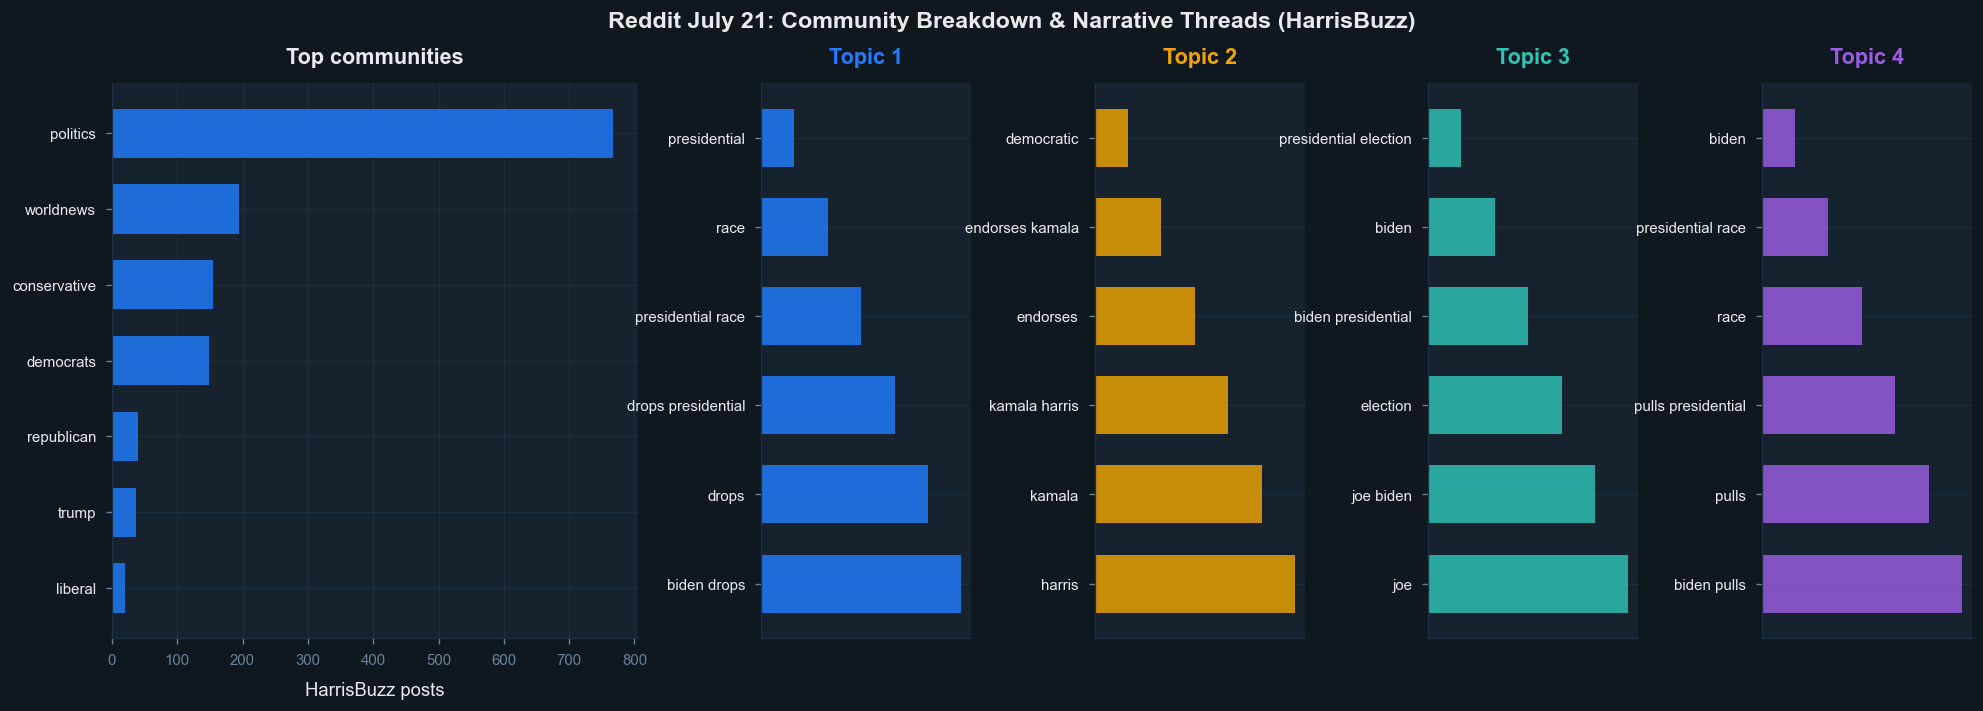

: 

In [ ]:
# ── Figure 2: Reddit community anatomy + NMF narrative threads ───────────────
top_subs = (r21[r21['candidate'] == 'HarrisBuzz']
            .groupby('subreddit').size()
            .sort_values(ascending=True)
            .tail(12))

TOPIC_COLORS = [DEMOCRAT, GOLD, TEAL, PURPLE]

fig = plt.figure(figsize=(20, 6))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Reddit July 21: Community Breakdown & Narrative Threads (HarrisBuzz)', fontweight='bold', fontsize=14)

# Gridspec: one wide subreddit panel + four narrow topic panels
from matplotlib.gridspec import GridSpec
gs = GridSpec(1, 5, figure=fig, width_ratios=[2.5, 1, 1, 1, 1], wspace=0.45)

# Left: top subreddits
ax_sub = fig.add_subplot(gs[0])
ax_sub.barh(range(len(top_subs)), top_subs.values, color=DEMOCRAT, alpha=0.82, height=0.65)
ax_sub.set_yticks(range(len(top_subs)))
ax_sub.set_yticklabels(top_subs.index, fontsize=9)
ax_sub.set_xlabel('HarrisBuzz posts')
ax_sub.set_title('Top communities', fontweight='bold')
ax_sub.set_facecolor(BG_PANEL)
ax_sub.tick_params(colors=TEXT_MUTED)
ax_sub.yaxis.set_tick_params(labelcolor=TEXT_PRIMARY)

# Four NMF topic panels
for t_idx, (t_words, t_color) in enumerate(zip(topics, TOPIC_COLORS)):
    ax_t = fig.add_subplot(gs[t_idx + 1])
    vals = list(range(N_WORDS, 0, -1))       # decreasing bar length = rank
    ax_t.barh(range(N_WORDS), vals, color=t_color, alpha=0.82, height=0.65)
    ax_t.set_yticks(range(N_WORDS))
    ax_t.set_yticklabels(t_words, fontsize=9)
    ax_t.set_xticks([])
    ax_t.set_title(f'Topic {t_idx + 1}', fontweight='bold', color=t_color)
    ax_t.set_facecolor(BG_PANEL)
    ax_t.tick_params(colors=TEXT_MUTED)
    ax_t.yaxis.set_tick_params(labelcolor=TEXT_PRIMARY)
    for spine in ax_t.spines.values():
        spine.set_edgecolor(SPINE_COLOR)

plt.show()


## 4 — Newspaper Coverage

Legacy media coverage (Mediacloud) shifted rapidly from a Trump-dominated landscape to a roughly balanced one. The upper panel shows raw article counts; the lower panel shows Trump's *share* of Trump+Harris coverage — as this drops below 60 %, Harris is absorbing the editorial spotlight that previously belonged to Biden.

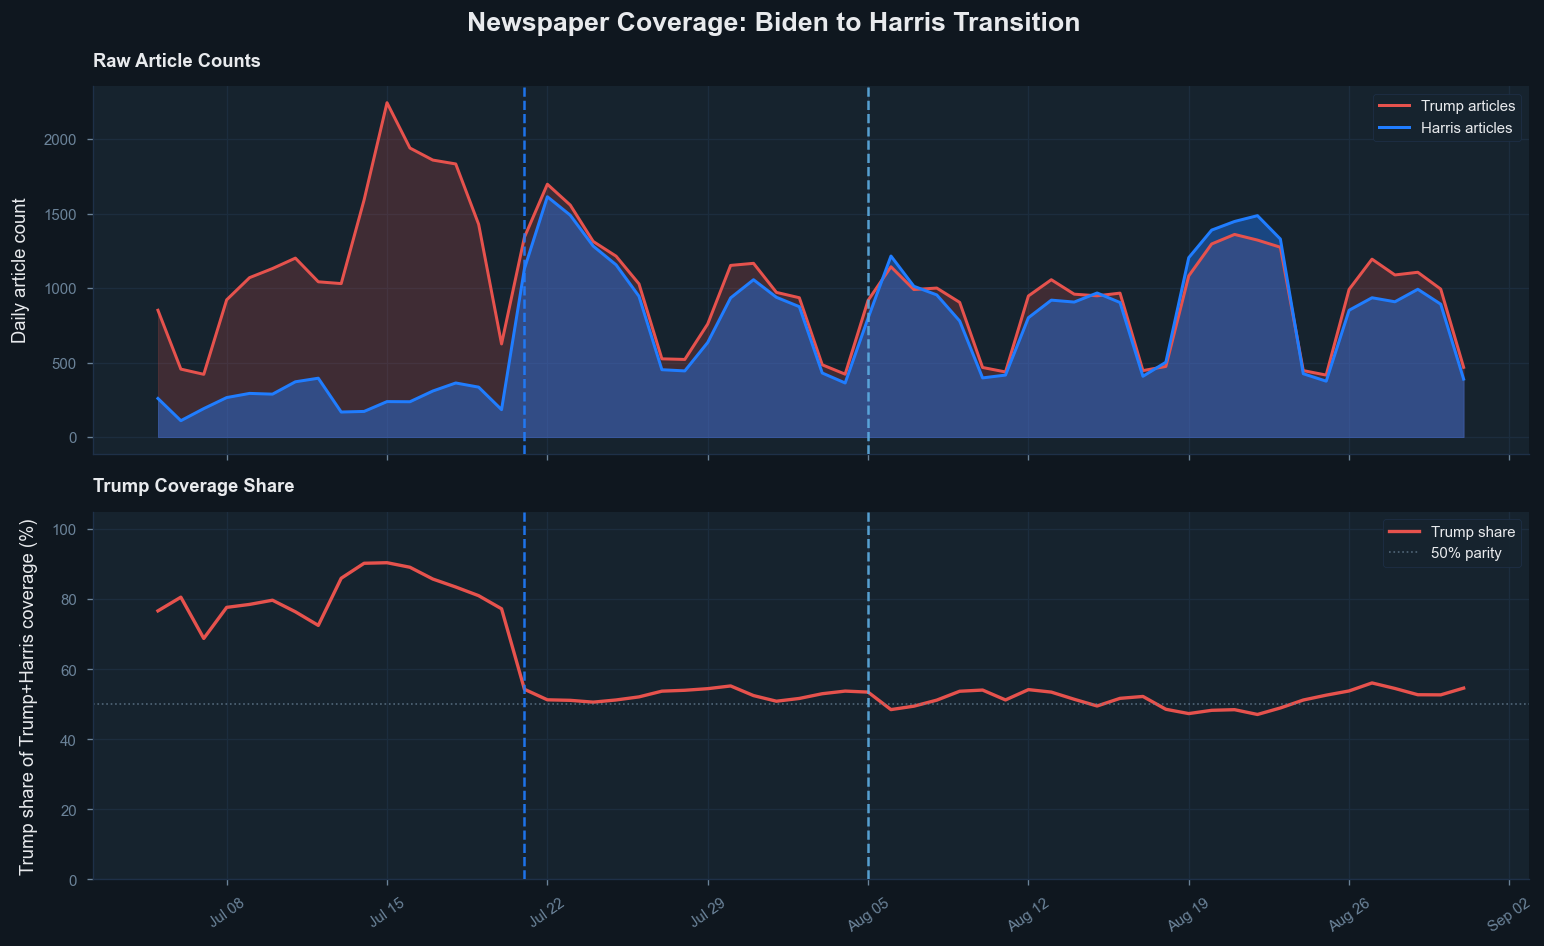

Before Biden out : Trump=1228  Harris=261  Trump-share=80.9%
Transition window: Trump=1000  Harris=909  Trump-share=52.7%
After Harris nom : Trump=914  Harris=877  Trump-share=51.4%


: 

In [ ]:
news   = pd.read_csv(os.path.join(DATA, '2_silver', 'newspapers', 'mediacloud_daily.csv'), parse_dates=['date'])
news_w = news[(news['date'] >= WINDOW_START) & (news['date'] <= WINDOW_END)].copy()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Newspaper Coverage: Biden to Harris Transition', fontweight='bold')

ax = axes[0]
ax.fill_between(news_w['date'], news_w['trump'],  alpha=0.2, color=REPUBLICAN)
ax.fill_between(news_w['date'], news_w['harris'], alpha=0.4, color=DEMOCRAT)
ax.plot(news_w['date'], news_w['trump'],  color=REPUBLICAN, linewidth=1.8, label='Trump articles')
ax.plot(news_w['date'], news_w['harris'], color=DEMOCRAT,   linewidth=1.8, label='Harris articles')
ax.axvline(BIDEN_OUT,  color=DEMOCRAT,          linestyle='--', linewidth=1.5, alpha=0.9, zorder=4)
ax.axvline(HARRIS_NOM, color=HARRIS_NOM_COLOR,  linestyle='--', linewidth=1.5, alpha=0.9, zorder=4)
ax.set_ylabel('Daily article count')
ax.set_title('Raw Article Counts', loc='left', fontsize=11)
ax.legend()

ax2 = axes[1]
ax2.plot(news_w['date'], news_w['trump_share'] * 100, color=REPUBLICAN, linewidth=2.0, label='Trump share')
ax2.axhline(50, color=TEXT_MUTED, linestyle=':', linewidth=1.0, alpha=0.7, label='50% parity')
ax2.axvline(BIDEN_OUT,  color=DEMOCRAT,         linestyle='--', linewidth=1.5, alpha=0.9, zorder=4)
ax2.axvline(HARRIS_NOM, color=HARRIS_NOM_COLOR, linestyle='--', linewidth=1.5, alpha=0.9, zorder=4)
fmt_date_axis(ax2)
ax2.set_ylabel('Trump share of Trump+Harris coverage (%)')
ax2.set_title('Trump Coverage Share', loc='left', fontsize=11)
ax2.set_ylim(0, 105)
ax2.legend()
plt.tight_layout()
plt.show()

before = news_w[news_w['date'] <  BIDEN_OUT]
during = news_w[(news_w['date'] >= BIDEN_OUT) & (news_w['date'] <= HARRIS_NOM)]
after  = news_w[news_w['date'] >  HARRIS_NOM]
for lbl, df in [('Before Biden out ', before), ('Transition window', during), ('After Harris nom ', after)]:
    if not df.empty:
        ts = df['trump_share'].mean() * 100
        print(f'{lbl}: Trump={df["trump"].mean():.0f}  Harris={df["harris"].mean():.0f}  Trump-share={ts:.1f}%')


## 5 — Market Fear ≠ Political Fear

The VIX (CBOE Volatility Index) spiked to **38.6 on August 5** — the same day Harris was formally nominated. At first glance this looks like political uncertainty driving markets. But it wasn't.

**The causal chain:** On July 31 the Bank of Japan unexpectedly raised interest rates. This triggered a massive unwinding of yen-carry-trade positions globally. On August 5 the Nikkei 225 fell ~12% in a single session, sending the VIX to its highest level since the COVID crash. This was a *global macro* event, not a US political one.

**How can we tell?** The NRC Emotion Lexicon lets us measure *fear* directly in newspaper text — word by word, across Democrat-leaning, Republican-leaning and centrist outlets. If the political transition were generating genuine fear, all three lean groups would show an elevated fear score on and after August 5. They don't.

The two series tell opposite stories on the same day: VIX explodes, newspaper fear stays flat. The divergence is the evidence.

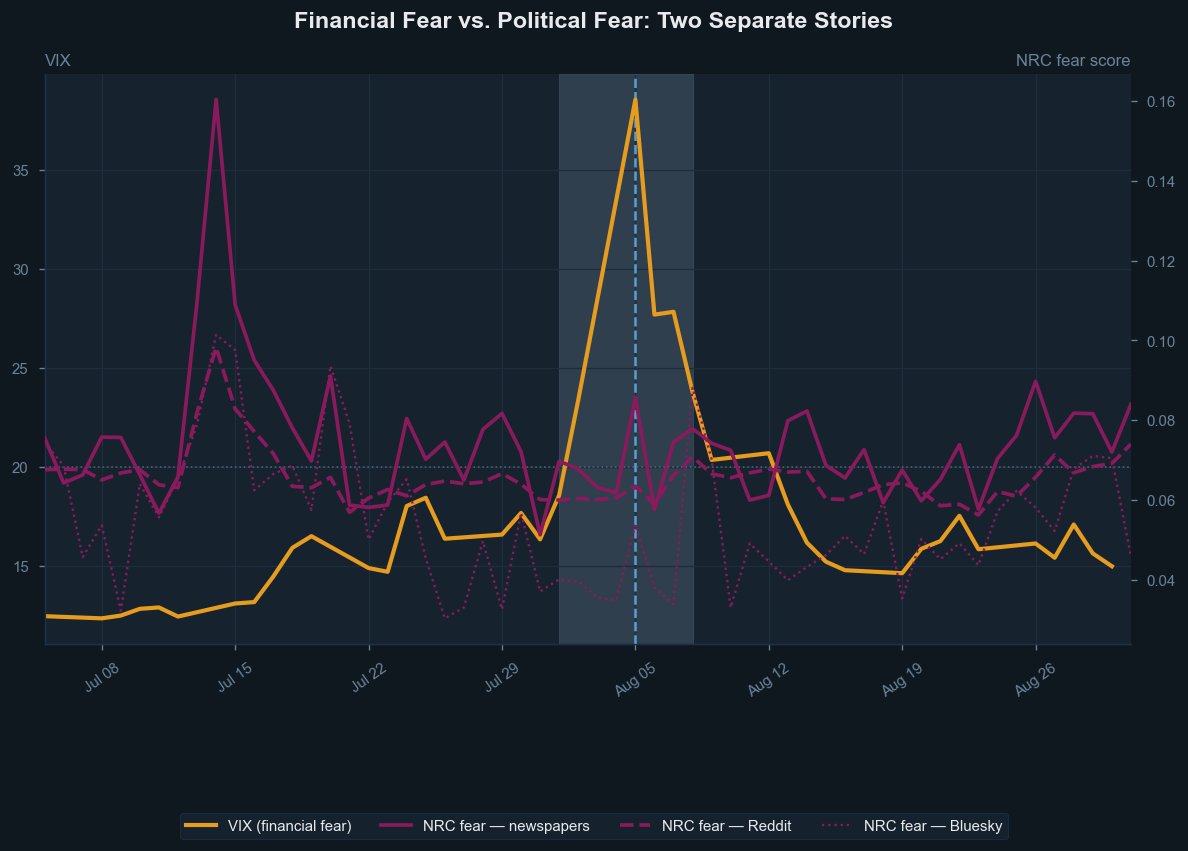

VIX peak: 38.6 on 2024-08-05
Avg VIX  Jul 1 – Jul 20  : 13.5
Avg VIX  Jul 21 – Aug 4  : 17.5
Avg VIX  Aug 5 – Aug 31  : 19.1


In [6]:
market   = pd.read_csv(os.path.join(DATA, '1_bronze', 'financials', 'market.csv'), parse_dates=['Date'])
market   = market.rename(columns={'Date': 'date'})
market_w = market[(market['date'] >= WINDOW_START) & (market['date'] <= WINDOW_END)].copy()

sent   = pd.read_csv(os.path.join(DATA, '2_silver', 'newspapers', 'sentiment_features_newspapers.csv'),
                     parse_dates=['date'])
sent_w = sent[(sent['date'] >= WINDOW_START) & (sent['date'] <= WINDOW_END)].copy()
sent_w['nrc_fear_avg'] = sent_w[['nrc_fear_dem', 'nrc_fear_rep', 'nrc_fear_cen']].mean(axis=1)

r_sent = pd.read_csv(os.path.join(DATA, '2_silver', 'reddit', 'sentiment_reddit.csv'), parse_dates=['date'])
r_sent['date'] = pd.to_datetime(r_sent['date'], utc=True).dt.normalize().dt.tz_localize(None)
r_sent_w = r_sent[(r_sent['date'] >= WINDOW_START) & (r_sent['date'] <= WINDOW_END)]
reddit_fear = r_sent_w.groupby('date')['fear'].mean().reset_index()

b_sent = pd.read_csv(os.path.join(DATA, '2_silver', 'bluesky', 'sentiment_bluesky.csv'), parse_dates=['date'])
b_sent['date'] = pd.to_datetime(b_sent['date'], utc=True).dt.normalize().dt.tz_localize(None)
b_sent_w = b_sent[(b_sent['date'] >= WINDOW_START) & (b_sent['date'] <= WINDOW_END)]
bluesky_fear = b_sent_w.groupby('date')['fear'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Financial Fear vs. Political Fear: Two Separate Stories',
             fontweight='bold', fontsize=14)

ax.axvspan(pd.Timestamp('2024-08-01'), pd.Timestamp('2024-08-08'),
           alpha=0.30, color=TEXT_MUTED, zorder=0)

# Left y-axis: VIX — house_style C_VIX
ax.set_axisbelow(True)
ax.grid(True)
ax.plot(market_w['date'], market_w['VIX'],
        color=C_VIX, linewidth=2.5, label='VIX (financial fear)', zorder=5)
ax.axhline(20, color=TEXT_MUTED, linestyle=':', linewidth=1.0, alpha=0.6, zorder=1)
ax.set_ylabel('')
ax.tick_params(axis='y', colors=TEXT_MUTED)
ax.text(0, 1.01, 'VIX', transform=ax.transAxes,
        color=TEXT_MUTED, fontsize=10, va='bottom', ha='left')
ax.set_facecolor(BG_PANEL)

# Right y-axis: NRC fear — house_style C_FEAR
ax2 = ax.twinx()
ax2.grid(False)
ax2.plot(sent_w['date'],       sent_w['nrc_fear_avg'], color=C_FEAR, linewidth=2.2,
         linestyle='-',  label='NRC fear — newspapers', zorder=5)
ax2.plot(reddit_fear['date'],  reddit_fear['fear'],    color=C_FEAR, linewidth=2.2,
         linestyle='--', label='NRC fear — Reddit',     zorder=5)
ax2.plot(bluesky_fear['date'], bluesky_fear['fear'],   color=C_FEAR, linewidth=1.4,
         linestyle=':',  label='NRC fear — Bluesky',    zorder=5)
ax2.set_ylabel('')
ax2.tick_params(axis='y', colors=TEXT_MUTED)
ax2.text(1, 1.01, 'NRC fear score', transform=ax2.transAxes,
         color=TEXT_MUTED, fontsize=10, va='bottom', ha='right')
ax2.set_facecolor(BG_PANEL)

ax.axvline(HARRIS_NOM, color=HARRIS_NOM_COLOR, linestyle='--', linewidth=1.5, alpha=0.9, zorder=4)

# Tight xlim: start at first actual market data point, end at WINDOW_END
x_left = market_w['date'].min()
ax.set_xlim(x_left, WINDOW_END)

fmt_date_axis(ax)

# Legend far below so you can crop it off
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
fig.legend(handles1 + handles2, labels1 + labels2,
           fontsize=9, loc='lower center',
           bbox_to_anchor=(0.5, -0.18), ncol=4,
           facecolor=BG_PANEL, edgecolor=SPINE_COLOR, labelcolor=TEXT_PRIMARY)

plt.tight_layout()
plt.show()

vix_peak_row = market_w.loc[market_w['VIX'].idxmax()]
peak_date    = vix_peak_row['date']
peak_vix     = vix_peak_row['VIX']
print(f'VIX peak: {peak_vix:.1f} on {peak_date.date()}')
print(f'Avg VIX  Jul 1 – Jul 20  : {market_w[market_w["date"] < BIDEN_OUT]["VIX"].mean():.1f}')
print(f'Avg VIX  Jul 21 – Aug 4  : {market_w[(market_w["date"] >= BIDEN_OUT) & (market_w["date"] < HARRIS_NOM)]["VIX"].mean():.1f}')
print(f'Avg VIX  Aug 5 – Aug 31  : {market_w[market_w["date"] >= HARRIS_NOM]["VIX"].mean():.1f}')

## 6 — Statistical Tests: Confirming What Moved (and What Didn't)

We formalise the visual impressions above with non-parametric Mann–Whitney U tests (robust to non-normal distributions). Each test compares the distribution of a daily metric *before Biden's withdrawal* to the distribution *during and after* the transition window.

**Key hypothesis:** Some things genuinely changed (Harris-related attention), while the underlying *political* fear signal in newspaper text did not — meaning the VIX spike on August 5 is attributable to external macro factors (yen carry trade), not to the political transition itself.

In [ ]:
# ── Helper: clean Mann-Whitney summary ───────────────────────────────────────
def mw_test(a, b, var_name, h0, alpha=0.05):
    u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
    sig  = 'YES *' if p < alpha else 'no'
    return {'variable': var_name, 'h0': h0, 'mean_before': np.mean(a),
            'mean_after': np.mean(b), 'p_value': p, 'significant': sig}

results = []

# 1. Reddit HarrisBuzz daily volume
rb = reddit_daily.get('HarrisBuzz', pd.Series(0, index=reddit_daily.index))
results.append(mw_test(
    rb[rb.index <  BIDEN_OUT].values,
    rb[rb.index >= BIDEN_OUT].values,
    'Reddit — HarrisBuzz daily posts',
    'No shift in HarrisBuzz volume'))

# 2. Bluesky HarrisBuzz daily volume
bb = bsky_daily.get('HarrisBuzz', pd.Series(0, index=bsky_daily.index))
results.append(mw_test(
    bb[bb.index <  BIDEN_OUT].values,
    bb[bb.index >= BIDEN_OUT].values,
    'Bluesky — HarrisBuzz daily posts',
    'No shift in HarrisBuzz volume'))

# 3. Newspaper Harris article count
results.append(mw_test(
    news_w[news_w['date'] <  BIDEN_OUT]['harris'].values,
    news_w[news_w['date'] >= BIDEN_OUT]['harris'].values,
    'Newspaper — Harris article count',
    'No shift in Harris coverage'))

# 4. Newspaper TOTAL article volume (should NOT change — no media panic)
results.append(mw_test(
    news_w[news_w['date'] <  BIDEN_OUT]['total_coverage'].values,
    news_w[news_w['date'] >= BIDEN_OUT]['total_coverage'].values,
    'Newspaper — TOTAL article volume',
    'No shift in total coverage volume'))

# 5. NRC fear avg — should NOT shift significantly (political calm, not political panic)
results.append(mw_test(
    sent_w[sent_w['date'] <  BIDEN_OUT]['nrc_fear_avg'].values,
    sent_w[sent_w['date'] >= BIDEN_OUT]['nrc_fear_avg'].values,
    'NRC fear avg (newspaper text)',
    'No shift in editorial fear'))

# 6. VIX before/after Harris nomination (Aug 5 = yen carry trade — financial, not political)
results.append(mw_test(
    market_w[market_w['date'] <  HARRIS_NOM]['VIX'].values,
    market_w[market_w['date'] >= HARRIS_NOM]['VIX'].values,
    'VIX — before / after Aug 5 (yen carry)',
    'No shift in market volatility'))

# 7. Trump's coverage share (should fall — confirming Harris takes space, not panic)
results.append(mw_test(
    news_w[news_w['date'] <  BIDEN_OUT]['trump_share'].values,
    news_w[news_w['date'] >= BIDEN_OUT]['trump_share'].values,
    "Newspaper — Trump's coverage share",
    'No shift in Trump share'))

print(f'{"Variable":<42} {"Mean before":>12} {"Mean after":>10} {"p-value":>10}  Sig?')
print('-' * 85)
for r in results:
    print(f'{r["variable"]:<42} {r["mean_before"]:>12.1f} {r["mean_after"]:>10.1f} {r["p_value"]:>10.4f}  {r["significant"]}')


Variable                                    Mean before Mean after    p-value  Sig?
-------------------------------------------------------------------------------------
Reddit — HarrisBuzz daily posts                   260.6      411.4     0.0274  YES *
Bluesky — HarrisBuzz daily posts                   14.5       83.3     0.0000  YES *
Newspaper — Harris article count                  261.1      889.1     0.0000  YES *
Newspaper — TOTAL article volume                 1569.1     1925.5     0.0834  no
NRC fear avg (newspaper text)                       0.1        0.0     0.0168  YES *
VIX — before / after Aug 5 (yen carry)             15.0       19.1     0.0070  YES *
Newspaper — Trump's coverage share                  0.8        0.5     0.0000  YES *


: 